# Fake News Detection using Machine Learning


#### 1. Import Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 2. Dataset Loading

In [12]:
true = pd.read_csv("../Dataset/True.csv")
fake = pd.read_csv("../Dataset/Fake.csv")

C:\Users\Dell\AppData\Local\Temp\ipykernel_23228\1955772209.py:2: DtypeWarning: Columns (0: Unnamed: 4, 1: Unnamed: 5, 2: Unnamed: 6, 3: Unnamed: 7, 4: Unnamed: 8, 5: Unnamed: 9, 6: Unnamed: 10, 7: Unnamed: 11, 8: Unnamed: 12, 9: Unnamed: 13, 10: Unnamed: 14, 11: Unnamed: 15, 12: Unnamed: 16, 13: Unnamed: 17, 14: Unnamed: 18, 15: Unnamed: 19, 16: Unnamed: 20, 17: Unnamed: 21, 18: Unnamed: 22, 19: Unnamed: 23, 20: Unnamed: 24, 21: Unnamed: 25, 22: Unnamed: 26, 23: Unnamed: 27, 24: Unnamed: 28, 25: Unnamed: 29, 26: Unnamed: 30, 27: Unnamed: 31, 28: Unnamed: 32, 29: Unnamed: 33, 30: Unnamed: 34, 31: Unnamed: 35, 32: Unnamed: 36, 33: Unnamed: 37, 34: Unnamed: 38, 35: Unnamed: 39, 36: Unnamed: 40, 37: Unnamed: 41, 38: Unnamed: 42, 39: Unnamed: 43, 40: Unnamed: 44, 41: Unnamed: 45, 42: Unnamed: 46, 43: Unnamed: 47, 44: Unnamed: 48, 45: Unnamed: 49, 46: Unnamed: 50, 47: Unnamed: 51, 48: Unnamed: 52, 49: Unnamed: 53, 50: Unnamed: 54, 51: Unnamed: 55, 52: Unnamed: 56, 53: Unnamed: 57, 54: Unnam

#### 3. Dataset Overview

In [13]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [14]:
fake.head()

,title,text,subject,date,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print("True Dataset Shape :", true.shape)
print("Fake Dataset Shape :", fake.shape)
print(true.columns)
print(fake.columns)
true.info()

True Dataset Shape : (21417, 4)
Fake Dataset Shape : (23502, 172)
Index(['title', 'text', 'subject', 'date'], dtype='str')
Index(['title', 'text', 'subject', 'date', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 162', 'Unnamed: 163', 'Unnamed: 164', 'Unnamed: 165',
       'Unnamed: 166', 'Unnamed: 167', 'Unnamed: 168', 'Unnamed: 169',
       'Unnamed: 170', 'Unnamed: 171'],
      dtype='str', length=172)
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 669.4 KB


In [16]:
fake.info()

<class 'pandas.DataFrame'>
RangeIndex: 23502 entries, 0 to 23501
Columns: 172 entries, title to Unnamed: 171
dtypes: str(172)
memory usage: 30.8 MB


In [17]:
# only first 4 columns rakhna
fake = fake[['title', 'text', 'subject', 'date']]

In [18]:
print(fake.shape)
print(fake.columns)

(23502, 4)
Index(['title', 'text', 'subject', 'date'], dtype='str')


### 3. Data Cleaning

#### 3.1 check missing values

In [19]:
print("True Dataset Missing Values")
print(true.isnull().sum())
print("\nFake Dataset Missing Values")
print(fake.isnull().sum())

True Dataset Missing Values
title      0
text       0
subject    0
date       0
dtype: int64

Fake Dataset Missing Values
title       0
text        0
subject    21
date       21
dtype: int64


#### 3.2 check duplicates values

In [20]:
print("True Duplicate Rows :", true.duplicated().sum())
print("Fake Duplicate Rows :", fake.duplicated().sum())

True Duplicate Rows : 206
Fake Duplicate Rows : 23


In [21]:
news = pd.concat([true, fake], ignore_index=True)
print("Before Removing Duplicates :", news.shape)

Before Removing Duplicates : (44919, 4)


#####  remove duplicate values

In [22]:
news = news.drop_duplicates()
print("After Removing Duplicates :", news.shape)

After Removing Duplicates : (44690, 4)


In [23]:
print(true["subject"].value_counts())

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


In [24]:
print(fake["subject"].value_counts())

subject
News                                                                                                                                                                                                                                                                                            9050
politics                                                                                                                                                                                                                                                                                        6838
left-news                                                                                                                                                                                                                                                                                       4457
Government News                                                                                                  

### 4. Exploratory Data Analysis (EDA)

In [25]:
import matplotlib.pyplot as plt
print("True News :", len(true))
print("Fake News :", len(fake))

True News : 21417
Fake News : 23502


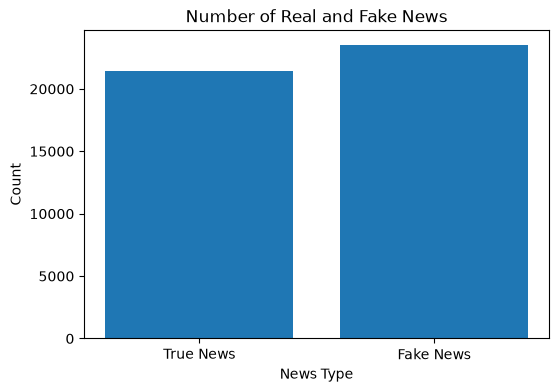

In [27]:
labels = ["True News", "Fake News"]
counts = [len(true), len(fake)]       #checked number of real and fake news articles

plt.figure(figsize=(6,4))
plt.bar(labels, counts)             #Bar chart for real vs fake 

plt.title("Number of Real and Fake News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.savefig("../Results/news_distribution.png")

plt.show()

In [28]:
true["subject"].value_counts()

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

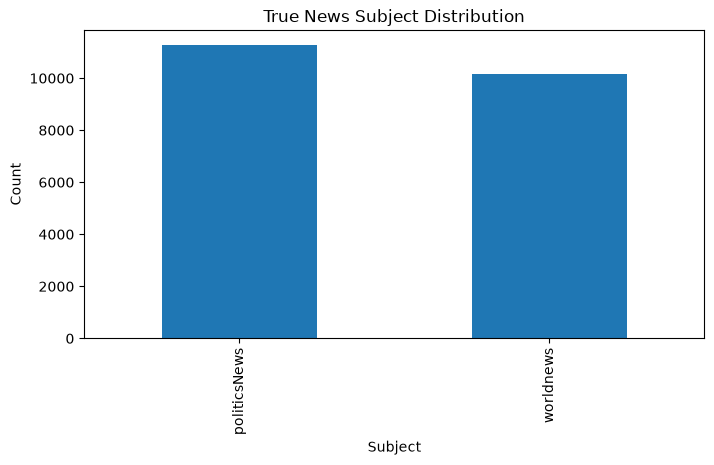

In [29]:
true["subject"].value_counts().plot(kind="bar", figsize=(8,4))

plt.title("True News Subject Distribution") # Subject distribution of true news
plt.xlabel("Subject")
plt.ylabel("Count")
plt.savefig("../Results/true_subject_distribution.png")

plt.show()

In [30]:
fake["subject"].value_counts()

subject
News                                                                                                                                                                                                                                                                                            9050
politics                                                                                                                                                                                                                                                                                        6838
left-news                                                                                                                                                                                                                                                                                       4457
Government News                                                                                                  

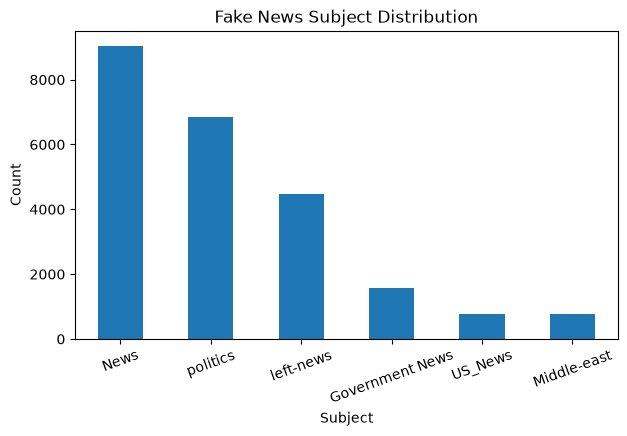

In [31]:
valid_subjects = [
    "News",
    "politics",
    "left-news",
    "Government News",
    "US_News",
    "Middle-east"
]

fake_subject = fake[fake["subject"].isin(valid_subjects)] # visualized subject distribution

fake_subject["subject"].value_counts().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Fake News Subject Distribution")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.savefig("../Results/Fake_Subject_Distribution.png")
plt.show()

In [32]:
true["text_length"] = true["text"].apply(len)
fake["text_length"] = fake["text"].apply(len)

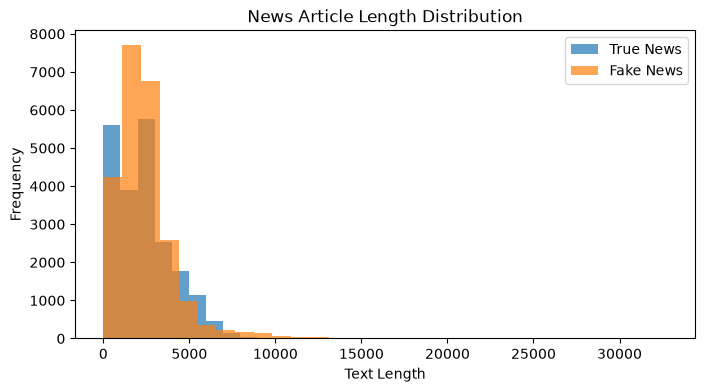

In [34]:
plt.figure(figsize=(8,4))

plt.hist(true["text_length"], bins=30, alpha=0.7, label="True News")
plt.hist(fake["text_length"], bins=30, alpha=0.7, label="Fake News")

plt.title("News Article Length Distribution") # Distribution of article length
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.savefig("../Results/article_length_distribution.png")
plt.legend()

plt.show()

In [35]:
true["label"] = 1       #changes labels true ->1 & false -> 0
fake["label"] = 0

In [36]:
true.head()

,title,text,subject,date,text_length,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",4659,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",4077,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",2789,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",2461,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",5204,1


In [37]:
fake.head()

,title,text,subject,date,text_length,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",2893,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1898,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",3597,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",2774,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",2346,0


#### 6. Dataset Merging (Real and Fake News)

In [38]:
news = pd.concat([true, fake], ignore_index=True)

In [39]:
news.shape

(44919, 6)

In [40]:
news = news.sample(frac=1, random_state=42)

In [41]:
news = news.reset_index(drop=True)  # Reset index

In [42]:
news.head()

,title,text,subject,date,text_length,label
0,Obama Announces ‘Unfinished Business’ For 201...,President Obama began the new year of 2016 wit...,News,"January 1, 2016",2153,0
1,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...,Chicago style politics buckle up America Barry...,left-news,"May 29, 2016",1520,0
2,White House says Obama will not discuss FBI pr...,ABOARD AIR FORCE ONE (Reuters) - President Bar...,politicsNews,"July 5, 2016",685,1
3,Treasury unit to share records with Senate for...,WASHINGTON (Reuters) - A unit of the U.S. Trea...,politicsNews,"May 12, 2017",1177,1
4,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...,Hollywood stars took to social media Wednesday...,left-news,"Jul 26, 2017",3426,0


In [43]:
news.columns

Index(['title', 'text', 'subject', 'date', 'text_length', 'label'], dtype='str')

In [44]:
news["content"] = news["title"] + " " + news["text"]      #combine title and text

In [45]:
news.head()

,title,text,subject,date,text_length,label,content
0,Obama Announces ‘Unfinished Business’ For 201...,President Obama began the new year of 2016 wit...,News,"January 1, 2016",2153,0,Obama Announces ‘Unfinished Business’ For 201...
1,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...,Chicago style politics buckle up America Barry...,left-news,"May 29, 2016",1520,0,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...
2,White House says Obama will not discuss FBI pr...,ABOARD AIR FORCE ONE (Reuters) - President Bar...,politicsNews,"July 5, 2016",685,1,White House says Obama will not discuss FBI pr...
3,Treasury unit to share records with Senate for...,WASHINGTON (Reuters) - A unit of the U.S. Trea...,politicsNews,"May 12, 2017",1177,1,Treasury unit to share records with Senate for...
4,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...,Hollywood stars took to social media Wednesday...,left-news,"Jul 26, 2017",3426,0,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...


In [46]:
news = news.drop(columns=["title", "text"])      # Drop unnecessary columns 

In [47]:
news.head()

,subject,date,text_length,label,content
0,News,"January 1, 2016",2153,0,Obama Announces ‘Unfinished Business’ For 201...
1,left-news,"May 29, 2016",1520,0,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...
2,politicsNews,"July 5, 2016",685,1,White House says Obama will not discuss FBI pr...
3,politicsNews,"May 12, 2017",1177,1,Treasury unit to share records with Senate for...
4,left-news,"Jul 26, 2017",3426,0,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...


In [48]:
news.info()

<class 'pandas.DataFrame'>
RangeIndex: 44919 entries, 0 to 44918
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   subject      44898 non-null  str  
 1   date         44898 non-null  str  
 2   text_length  44919 non-null  int64
 3   label        44919 non-null  int64
 4   content      44919 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.7 MB


In [51]:
news.to_csv("../Dataset/cleaned_news.csv", index=False)

In [53]:
saved_news = pd.read_csv("../Dataset/cleaned_news.csv")

saved_news.head()

,subject,date,text_length,label,content
0,News,"January 1, 2016",2153,0,Obama Announces ‘Unfinished Business’ For 201...
1,left-news,"May 29, 2016",1520,0,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...
2,politicsNews,"July 5, 2016",685,1,White House says Obama will not discuss FBI pr...
3,politicsNews,"May 12, 2017",1177,1,Treasury unit to share records with Senate for...
4,left-news,"Jul 26, 2017",3426,0,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...


#### 7. Text Preprocessing

In [54]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [55]:
# all cases to remove :  1. convert into lowercase
#                        2. remove punctuation and numbers
#                        3. split text into words
#                        4. remove stopwords
#                        5. join words again
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = " ".join(words)
    return text

In [56]:
news.head()

,subject,date,text_length,label,content
0,News,"January 1, 2016",2153,0,Obama Announces ‘Unfinished Business’ For 201...
1,left-news,"May 29, 2016",1520,0,IT BEGINS….OBAMA APPOINTED JUDGE Rules Trump U...
2,politicsNews,"July 5, 2016",685,1,White House says Obama will not discuss FBI pr...
3,politicsNews,"May 12, 2017",1177,1,Treasury unit to share records with Senate for...
4,left-news,"Jul 26, 2017",3426,0,HOLLYWOOD LIBS HAVE EPIC MELT DOWNS…Threaten P...


In [58]:
news.to_csv("../Dataset/cleaned_news.csv", index=False) # Save cleaned dataset


#### 7. Bag of Words 
-for camparion only

In [59]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer( 
    stop_words="english",
    max_features=5000
)

In [60]:
X_bow = bow_vectorizer.fit_transform(news["content"]) # Convert text into BOW
print("Bag of Words Shape :", X_bow.shape)
print(bow_vectorizer.get_feature_names_out()[:20])

Bag of Words Shape : (44919, 5000)
['00' '000' '10' '100' '11' '12' '120' '13' '14' '15' '150' '16' '17' '18'
 '19' '1980s' '1990s' '1992' '1993' '1994']


In [62]:
import joblib
joblib.dump(bow_vectorizer, "../Saved Model/bow_vectorizer.pkl") # Save BOW vectorizer
print("Bag of Words Vectorizer Saved Successfully!")

Bag of Words Vectorizer Saved Successfully!


#### 8. TF-IDF 

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer #import TF-IDF

In [64]:
vectorizer = TfidfVectorizer(  #create
    stop_words="english",
    max_features=5000
)

In [65]:
X = vectorizer.fit_transform(news["content"])  # Convert text into TF-IDF features
y = news["label"]   #target variable

In [66]:
print("TF-IDF Shape :", X.shape)  # Display feature matrix shape

TF-IDF Shape : (44919, 5000)


In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (35935, 5000)
X_test : (8984, 5000)
y_train : (35935,)
y_test : (8984,)


In [71]:
joblib.dump(vectorizer, "../Saved Model/tfidf_vectorizer.pkl")  # Save TF-IDF
print("TF-IDF Vectorizer Saved Successfully!")

TF-IDF Vectorizer Saved Successfully!


### Model Training 

#### 9. Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression #import LR
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
model = LogisticRegression(max_iter=1000) # create LR model

In [74]:
model.fit(X_train, y_train) #train model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
y_pred = model.predict(X_test) #make predictions

In [76]:
accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy

print("Accuracy :", accuracy)


Accuracy : 0.9868655387355298


In [77]:
from sklearn.metrics import classification_report  # classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4666
           1       0.98      0.99      0.99      4318

    accuracy                           0.99      8984
   macro avg       0.99      0.99      0.99      8984
weighted avg       0.99      0.99      0.99      8984



In [78]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred) # confusion matrix
print(cm)

[[4589   77]
 [  41 4277]]


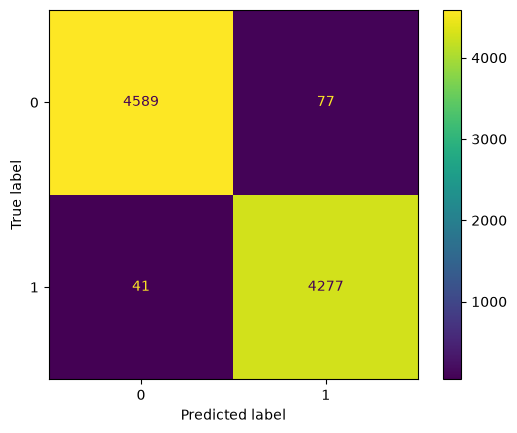

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.savefig("../Results/confusion_matrix_LR.png")

In [82]:
import joblib
joblib.dump(model, "../Saved Model/logistic_model.pkl")
joblib.dump(vectorizer, "../Saved Model/tfidf_vectorizer.pkl") # Save trained model
print("Model Saved Successfully!")

Model Saved Successfully!


#### 10. Naive Bayes

In [83]:
from sklearn.naive_bayes import MultinomialNB # Import NB
nb = MultinomialNB()   #create model

nb.fit(X_train, y_train)      # train model
nb_pred = nb.predict(X_test)  # make predictions

In [84]:
from sklearn.metrics import accuracy_score # accuracy score

nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.9295414069456812


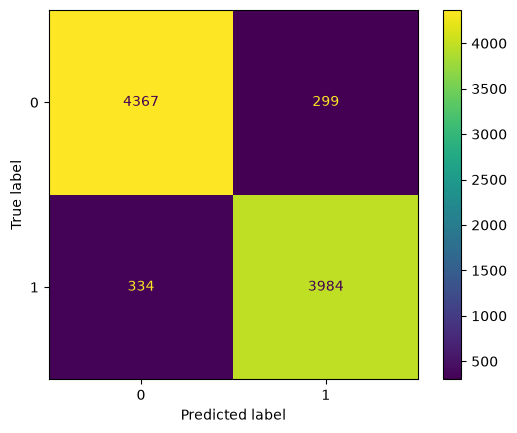

In [87]:
import matplotlib.pyplot as plt   
from sklearn.metrics import ConfusionMatrixDisplay  # confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.savefig("../Results/confusion_matrix_NB.png")
plt.show()

In [88]:
joblib.dump(nb, "../Saved Model/naive_bayes_model.pkl")
print("Naive Bayes Model Saved Successfully!")  #save model 

Naive Bayes Model Saved Successfully!


#### 11. Random Forest

In [89]:
from sklearn.ensemble import RandomForestClassifier # import RF

In [90]:
rf = RandomForestClassifier(   # create model
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train) #train model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [91]:
rf_pred = rf.predict(X_test)  # make predictions
rf_accuracy = accuracy_score(y_test, rf_pred) #accuracy score
 
print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9951024042742653


In [92]:
print(classification_report(y_test, rf_pred)) # classification report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4666
           1       1.00      0.99      0.99      4318

    accuracy                           1.00      8984
   macro avg       1.00      1.00      1.00      8984
weighted avg       1.00      1.00      1.00      8984



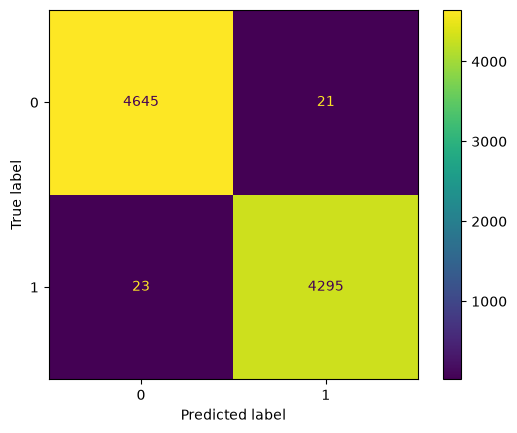

In [95]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred) # confusion matrix
plt.savefig("../Results/confusion_matrix_RF.png")
plt.show()

In [96]:
joblib.dump(rf, "../Saved Model/random_forest_model.pkl") # save model
print("Random Forest Model Saved Successfully!")

Random Forest Model Saved Successfully!


#### 12. K-Nearest Neighbors (KNN)

In [97]:
from sklearn.neighbors import KNeighborsClassifier  # import KNN

In [98]:
knn = KNeighborsClassifier(n_neighbors=5) #create model

In [99]:
knn.fit(X_train, y_train) #train model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [100]:
knn_pred = knn.predict(X_test) #make predictions

In [101]:
knn_accuracy = accuracy_score(y_test, knn_pred) #accuracy score

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.8870213713268033


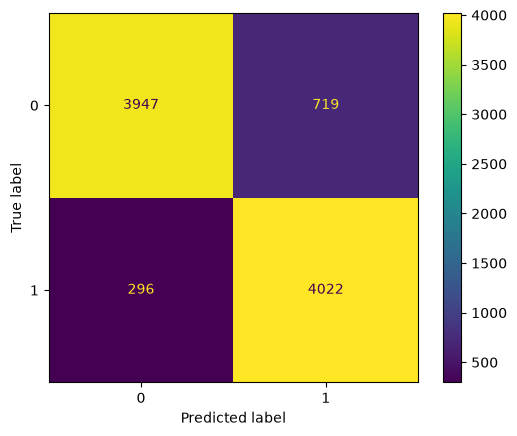

In [104]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_pred) # confusion matrix
plt.savefig("../Results/confusion_matrix_KNN.png")
plt.show()

In [105]:
joblib.dump(knn, "../Saved Model/knn_model.pkl") # save model
print("KNN Model Saved Successfully!")

KNN Model Saved Successfully!


### 13. Neural Network (MLPClassifier)

In [106]:
from sklearn.neural_network import MLPClassifier  #import NN

In [107]:
mlp = MLPClassifier(          # create model
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42 )

In [109]:
mlp.fit(X_train, y_train) #train model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [110]:
mlp_pred = mlp.predict(X_test) #make predictions

In [111]:
mlp_accuracy = accuracy_score(y_test, mlp_pred) #accuracy score

print("Neural Network Accuracy :", mlp_accuracy)

Neural Network Accuracy : 0.9925422974176313


In [112]:
print(classification_report(y_test, mlp_pred)) # classification report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4666
           1       0.99      0.99      0.99      4318

    accuracy                           0.99      8984
   macro avg       0.99      0.99      0.99      8984
weighted avg       0.99      0.99      0.99      8984



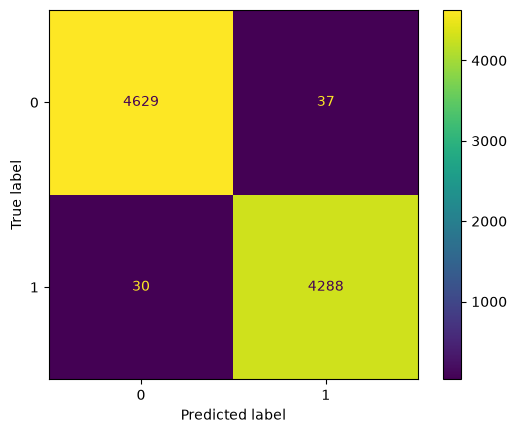

In [113]:
ConfusionMatrixDisplay.from_predictions(y_test, mlp_pred)
plt.savefig("../Results/confusion_matrix_NN.png")
plt.show()

In [114]:
joblib.dump(mlp, "../Saved Model/neural_network_model.pkl") # save model
print("Neural Network Model Saved Successfully!")

Neural Network Model Saved Successfully!


### 14. Model Comparison

In [115]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest","KNN","Neural Network"],
    "Accuracy": [       # Create model comparison table
        accuracy,
        nb_accuracy,
        rf_accuracy,
        knn_accuracy,
        mlp_accuracy
    ]
}
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.986866
1,Naive Bayes,0.929541
2,Random Forest,0.995102
3,KNN,0.887021
4,Neural Network,0.992542


In [116]:
results_df.to_csv("../Results/model_results.csv", index=False)  # Save model results
print("Model Results Saved Successfully!")

Model Results Saved Successfully!


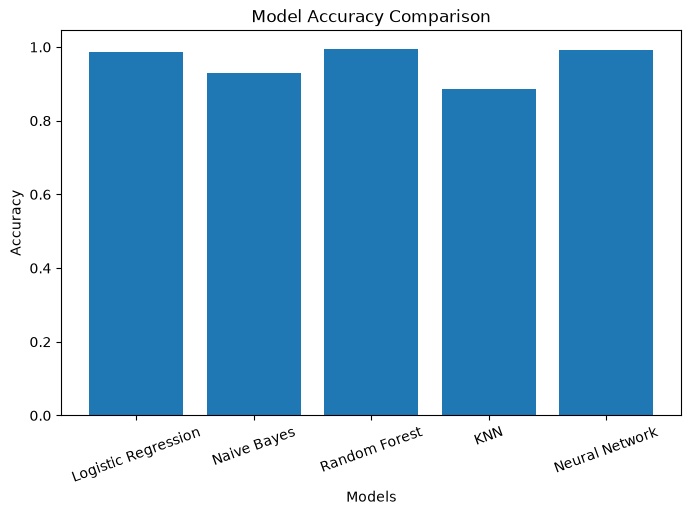

In [117]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")         # Save comparison graph
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.savefig("../Results/model_accuracy.png")

plt.show()

In [118]:
best_model = results_df.loc[results_df["Accuracy"].idxmax()]
print(best_model) # Find the best performing model

Model       Random Forest
Accuracy         0.995102
Name: 2, dtype: object


### 15. Custom Prediction

In [119]:
#Trail-1 => { CUSTOM NEWS }
sample_news = ["India launches a new AI education program for students."]
sample_vector = vectorizer.transform(sample_news)
prediction = model.predict(sample_vector)
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Result : Real News")
else:
    print("Result : Fake News")

#Trail-2
sample_news = [ "NASA successfully launched a new satellite into space on Monday."]

sample_vector = vectorizer.transform(sample_news)
prediction = model.predict(sample_vector)
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Result : Real News")
else:
    print("Result : Fake News")

#Trail-4
sample_news = [
    "The Earth is flat according to new government research."
]
sample_vector = vectorizer.transform(sample_news)
prediction = model.predict(sample_vector)
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Result : Real News")
else:
    print("Result : Fake News")

sample_news = [news["content"].iloc[10]]
print(news["label"].iloc[10])

Prediction: 0
Result : Fake News
Prediction: 1
Result : Real News
Prediction: 0
Result : Fake News
1
